In [4]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd

from src.finbert import add_finbert_signal

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
news_panel = pd.read_csv(PROJECT_ROOT / "data/processed/news_price_panel.csv")
news_panel["date"] = pd.to_datetime(news_panel["date"])

news_panel.shape

(1487, 10)

In [8]:
news_finbert = add_finbert_signal(
    news_panel,
    text_col="text",
    batch_size=16,
    max_length=128
)

news_finbert.head()

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  0%|                                                                                                 | 0/93 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

100%|████████████████████████████████████████████████████████████████████████████████████████| 93/93 [00:18<00:00,  4.90it/s]


,date,ticker,close,ret_1d,fwd_ret_1d,fwd_ret_5d,vol_20d,vol_20d_ann,text,num_headlines,finbert_positive,finbert_negative,finbert_neutral,signal_finbert
0,2020-03-09,AAPL,64.254387,-0.079092,0.072021,-0.090018,0.038139,0.605441,Crude Awakening: Energy Sector Takes A 20% Spi...,3,0.072669,0.827072,0.100259,-0.754402
1,2020-03-10,AAPL,68.882072,0.072021,-0.034731,-0.113829,0.042126,0.668726,Peloton Shares Tick To Session Low As Hearing ...,8,0.047382,0.934005,0.018613,-0.886623
2,2020-03-11,AAPL,66.489761,-0.034731,-0.098755,-0.104419,0.042644,0.676953,Here's How Large Option Traders Are Playing Hi...,13,0.083729,0.876060,0.040212,-0.792331
3,2020-03-12,AAPL,59.923592,-0.098755,0.119808,-0.013898,0.046670,0.740865,Selling Picks Up In Worst Day Since 1987 As Fe...,6,0.008262,0.969886,0.021852,-0.961623
4,2020-03-13,AAPL,67.102943,0.119808,-0.128647,-0.175307,0.055299,0.877838,Canopy Growth's Storz & Bickel Bypasses Apple'...,11,0.746394,0.183995,0.069610,0.562399


In [9]:
news_finbert.to_csv(
    PROJECT_ROOT / "data/processed/news_finbert_panel.csv",
    index=False
)

In [10]:
news_finbert[
    ["date", "ticker", "text", "finbert_positive", "finbert_negative", "finbert_neutral", "signal_finbert"]
].head(10)

news_finbert["signal_finbert"].describe()

count    1487.000000
mean        0.012221
std         0.730418
min        -0.966360
25%        -0.887535
50%         0.080933
75%         0.794953
max         0.943311
Name: signal_finbert, dtype: float64

In [12]:
from src.portfolio import make_signal_weighted_long_short_weights
from src.backtest import run_backtest, compute_turnover, apply_transaction_costs
from src.metrics import summarize_returns
from src.risk import (
    check_weight_constraints,
    clip_and_renormalize_weights,
    apply_turnover_limit,
    summarize_constraint_violations,
)

In [13]:
def run_finbert_strategy_with_risk_repair(
    signal_col="signal_finbert",
    top_k=5,
    bottom_k=5,
    max_abs_weight=0.10,
    max_turnover=0.50,
    cost_bps=5.0
):
    # 1. Naive signal-weighted allocation
    weights_naive = make_signal_weighted_long_short_weights(
        signal_df=news_finbert,
        signal_col=signal_col,
        top_k=top_k,
        bottom_k=bottom_k,
        gross_exposure=1.0
    )

    # 2. Constraint check: naive
    naive_constraints = check_weight_constraints(
        weights_naive,
        max_abs_weight=max_abs_weight
    )

    naive_violation_summary = summarize_constraint_violations(
        naive_constraints
    )

    # 3. Repair weights
    weights_repaired = clip_and_renormalize_weights(
        weights_naive,
        max_abs_weight=max_abs_weight,
        target_gross_exposure=1.0
    )

    weights_repaired = apply_turnover_limit(
        weights_repaired,
        max_turnover=max_turnover
    )

    # 4. Constraint check: repaired
    repaired_constraints = check_weight_constraints(
        weights_repaired,
        max_abs_weight=max_abs_weight
    )

    repaired_violation_summary = summarize_constraint_violations(
        repaired_constraints
    )

    # 5. Backtest naive
    returns_naive = run_backtest(
        weights=weights_naive,
        panel=news_finbert,
        forward_return_col="fwd_ret_1d"
    )

    turnover_naive = compute_turnover(weights_naive)

    bt_naive = apply_transaction_costs(
        portfolio_returns=returns_naive,
        turnover=turnover_naive,
        cost_bps=cost_bps
    )

    metrics_naive = summarize_returns(bt_naive["portfolio_return_net"])
    metrics_naive["avg_turnover"] = bt_naive["turnover"].mean()
    metrics_naive["violation_rate"] = naive_violation_summary["violation_rate"]
    metrics_naive["avg_max_abs_weight"] = naive_violation_summary["avg_max_abs_weight"]

    # 6. Backtest repaired
    returns_repaired = run_backtest(
        weights=weights_repaired,
        panel=news_finbert,
        forward_return_col="fwd_ret_1d"
    )

    turnover_repaired = compute_turnover(weights_repaired)

    bt_repaired = apply_transaction_costs(
        portfolio_returns=returns_repaired,
        turnover=turnover_repaired,
        cost_bps=cost_bps
    )

    metrics_repaired = summarize_returns(bt_repaired["portfolio_return_net"])
    metrics_repaired["avg_turnover"] = bt_repaired["turnover"].mean()
    metrics_repaired["violation_rate"] = repaired_violation_summary["violation_rate"]
    metrics_repaired["avg_max_abs_weight"] = repaired_violation_summary["avg_max_abs_weight"]

    return {
        "bt_naive": bt_naive,
        "bt_repaired": bt_repaired,
        "weights_naive": weights_naive,
        "weights_repaired": weights_repaired,
        "metrics_naive": metrics_naive,
        "metrics_repaired": metrics_repaired,
    }

In [14]:
res_finbert = run_finbert_strategy_with_risk_repair(
    signal_col="signal_finbert",
    top_k=5,
    bottom_k=5,
    max_abs_weight=0.10,
    max_turnover=0.50,
    cost_bps=5.0
)

finbert_metrics_table = pd.DataFrame([
    {"strategy": "finbert_naive", **res_finbert["metrics_naive"]},
    {"strategy": "finbert_repaired", **res_finbert["metrics_repaired"]},
])

finbert_metrics_table

,strategy,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,avg_turnover,violation_rate,avg_max_abs_weight
0,finbert_naive,0.062269,0.191406,0.410095,-0.173976,1.530877,1.0,0.191675
1,finbert_repaired,0.089002,0.079470,1.112376,-0.033080,0.504808,0.0,0.078693


In [15]:
finbert_metrics_table.to_csv(
    PROJECT_ROOT / "results/tables/finbert_naive_vs_repaired.csv",
    index=False
)

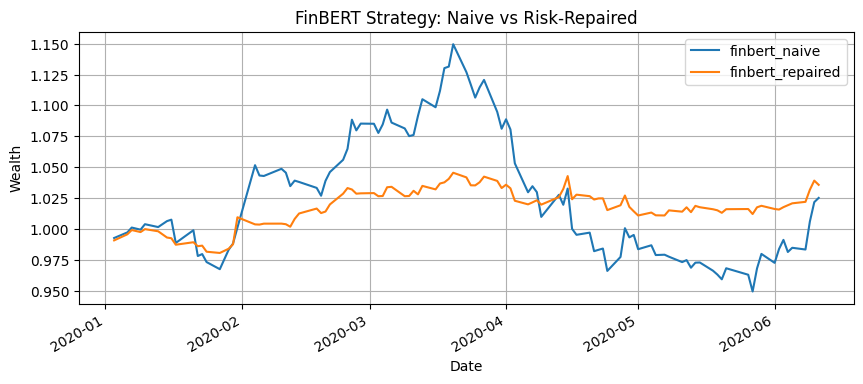

In [16]:
import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    "date": res_finbert["bt_naive"]["date"],
    "finbert_naive": (1.0 + res_finbert["bt_naive"]["portfolio_return_net"]).cumprod(),
    "finbert_repaired": (1.0 + res_finbert["bt_repaired"]["portfolio_return_net"]).cumprod(),
})

plot_df.plot(
    x="date",
    y=["finbert_naive", "finbert_repaired"],
    figsize=(10, 4),
    title="FinBERT Strategy: Naive vs Risk-Repaired"
)

plt.xlabel("Date")
plt.ylabel("Wealth")
plt.grid(True)
plt.show()

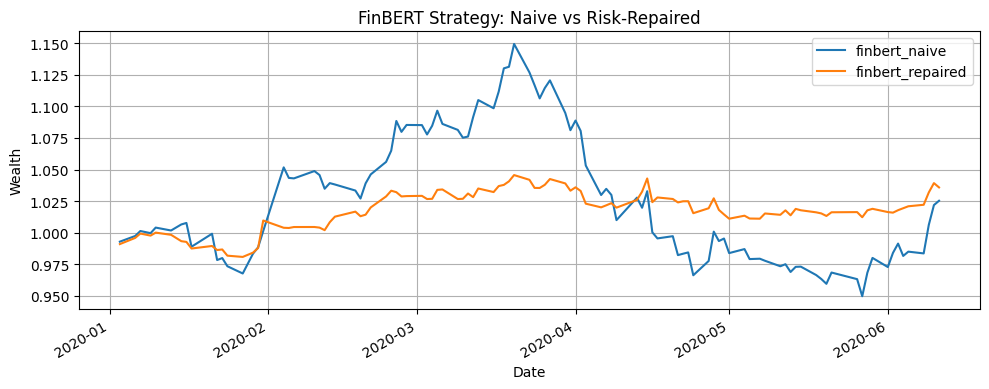

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))

plot_df.plot(
    x="date",
    y=["finbert_naive", "finbert_repaired"],
    ax=ax,
    title="FinBERT Strategy: Naive vs Risk-Repaired"
)

ax.set_xlabel("Date")
ax.set_ylabel("Wealth")
ax.grid(True)

fig.tight_layout()

fig.savefig(
    PROJECT_ROOT / "results/figures/finbert_naive_vs_repaired_wealth.png",
    dpi=300
)

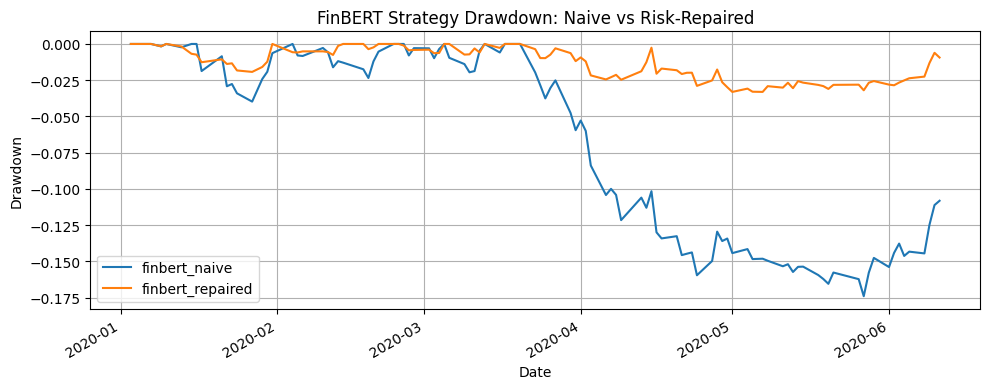

In [18]:
def compute_drawdown_from_returns(returns):
    wealth = (1.0 + returns).cumprod()
    running_max = wealth.cummax()
    return wealth / running_max - 1.0


dd_df = pd.DataFrame({
    "date": res_finbert["bt_naive"]["date"],
    "finbert_naive": compute_drawdown_from_returns(
        res_finbert["bt_naive"]["portfolio_return_net"]
    ),
    "finbert_repaired": compute_drawdown_from_returns(
        res_finbert["bt_repaired"]["portfolio_return_net"]
    ),
})

fig, ax = plt.subplots(figsize=(10, 4))

dd_df.plot(
    x="date",
    y=["finbert_naive", "finbert_repaired"],
    ax=ax,
    title="FinBERT Strategy Drawdown: Naive vs Risk-Repaired"
)

ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.grid(True)

fig.tight_layout()

fig.savefig(
    PROJECT_ROOT / "results/figures/finbert_naive_vs_repaired_drawdown.png",
    dpi=300
)

plt.show()

In [19]:
res_finbert["bt_naive"].to_csv(
    PROJECT_ROOT / "results/tables/finbert_naive_backtest.csv",
    index=False
)

res_finbert["bt_repaired"].to_csv(
    PROJECT_ROOT / "results/tables/finbert_repaired_backtest.csv",
    index=False
)

In [20]:
from src.eval_signals import (
    directional_accuracy,
    rank_ic_by_date,
    summarize_rank_ic,
    bucket_return_analysis,
    top_minus_bottom_return,
)

In [21]:
acc_1d = directional_accuracy(
    news_finbert,
    signal_col="signal_finbert",
    return_col="fwd_ret_1d"
)

acc_5d = directional_accuracy(
    news_finbert,
    signal_col="signal_finbert",
    return_col="fwd_ret_5d"
)

acc_1d, acc_5d

(0.468728984532616, 0.531271015467384)

In [22]:
ic_1d = rank_ic_by_date(
    news_finbert,
    signal_col="signal_finbert",
    return_col="fwd_ret_1d"
)

ic_5d = rank_ic_by_date(
    news_finbert,
    signal_col="signal_finbert",
    return_col="fwd_ret_5d"
)

ic_summary_1d = summarize_rank_ic(ic_1d)
ic_summary_5d = summarize_rank_ic(ic_5d)

ic_summary_1d, ic_summary_5d

({'mean_rank_ic': 0.017233811744206965,
  'median_rank_ic': 0.02132861509064735,
  'ic_positive_rate': 0.5267857142857143,
  'num_dates': 112},
 {'mean_rank_ic': 0.023892151318084937,
  'median_rank_ic': -0.007463926992976917,
  'ic_positive_rate': 0.48214285714285715,
  'num_dates': 112})

In [23]:
bucket_1d = bucket_return_analysis(
    news_finbert,
    signal_col="signal_finbert",
    return_col="fwd_ret_1d",
    num_buckets=5
)

bucket_5d = bucket_return_analysis(
    news_finbert,
    signal_col="signal_finbert",
    return_col="fwd_ret_5d",
    num_buckets=5
)

bucket_1d

,bucket,avg_signal,avg_future_return,median_future_return,count
0,0,-0.959151,0.006458,0.010525,298
1,1,-0.615506,0.004224,0.001845,297
2,2,0.093614,0.000093,0.001279,298
3,3,0.637207,0.000419,0.000543,296
4,4,0.907025,-0.000668,-0.002116,298


In [27]:
bucket_5d

,bucket,avg_signal,avg_future_return,median_future_return,count
0,0,-0.959151,-0.011714,-0.004414,298
1,1,-0.615506,0.015504,0.010773,297
2,2,0.093614,0.004854,0.009060,298
3,3,0.637207,0.008916,0.011158,296
4,4,0.907025,0.013390,0.009894,298


In [24]:
tmb_1d = top_minus_bottom_return(bucket_1d)
tmb_5d = top_minus_bottom_return(bucket_5d)

tmb_1d, tmb_5d

(-0.007125345800515718, 0.025103560841090822)

In [25]:
signal_quality_table = pd.DataFrame([
    {
        "horizon": "1d",
        "directional_accuracy": acc_1d,
        **ic_summary_1d,
        "top_minus_bottom_return": tmb_1d,
    },
    {
        "horizon": "5d",
        "directional_accuracy": acc_5d,
        **ic_summary_5d,
        "top_minus_bottom_return": tmb_5d,
    },
])

signal_quality_table

,horizon,directional_accuracy,mean_rank_ic,median_rank_ic,ic_positive_rate,num_dates,top_minus_bottom_return
0,1d,0.468729,0.017234,0.021329,0.526786,112,-0.007125
1,5d,0.531271,0.023892,-0.007464,0.482143,112,0.025104


In [26]:
signal_quality_table.to_csv(
    PROJECT_ROOT / "results/tables/finbert_signal_quality.csv",
    index=False
)

bucket_1d.to_csv(
    PROJECT_ROOT / "results/tables/finbert_bucket_returns_1d.csv",
    index=False
)

bucket_5d.to_csv(
    PROJECT_ROOT / "results/tables/finbert_bucket_returns_5d.csv",
    index=False
)

In [28]:
def run_finbert_strategy_with_risk_repair_horizon(
    signal_col="signal_finbert",
    forward_return_col="fwd_ret_5d",
    top_k=5,
    bottom_k=5,
    max_abs_weight=0.10,
    max_turnover=0.50,
    cost_bps=5.0
):
    weights_naive = make_signal_weighted_long_short_weights(
        signal_df=news_finbert,
        signal_col=signal_col,
        top_k=top_k,
        bottom_k=bottom_k,
        gross_exposure=1.0
    )

    naive_constraints = check_weight_constraints(
        weights_naive,
        max_abs_weight=max_abs_weight
    )

    naive_violation_summary = summarize_constraint_violations(
        naive_constraints
    )

    weights_repaired = clip_and_renormalize_weights(
        weights_naive,
        max_abs_weight=max_abs_weight,
        target_gross_exposure=1.0
    )

    weights_repaired = apply_turnover_limit(
        weights_repaired,
        max_turnover=max_turnover
    )

    repaired_constraints = check_weight_constraints(
        weights_repaired,
        max_abs_weight=max_abs_weight
    )

    repaired_violation_summary = summarize_constraint_violations(
        repaired_constraints
    )

    returns_naive = run_backtest(
        weights=weights_naive,
        panel=news_finbert,
        forward_return_col=forward_return_col
    )

    turnover_naive = compute_turnover(weights_naive)

    bt_naive = apply_transaction_costs(
        portfolio_returns=returns_naive,
        turnover=turnover_naive,
        cost_bps=cost_bps
    )

    metrics_naive = summarize_returns(bt_naive["portfolio_return_net"])
    metrics_naive["avg_turnover"] = bt_naive["turnover"].mean()
    metrics_naive["violation_rate"] = naive_violation_summary["violation_rate"]
    metrics_naive["avg_max_abs_weight"] = naive_violation_summary["avg_max_abs_weight"]

    returns_repaired = run_backtest(
        weights=weights_repaired,
        panel=news_finbert,
        forward_return_col=forward_return_col
    )

    turnover_repaired = compute_turnover(weights_repaired)

    bt_repaired = apply_transaction_costs(
        portfolio_returns=returns_repaired,
        turnover=turnover_repaired,
        cost_bps=cost_bps
    )

    metrics_repaired = summarize_returns(bt_repaired["portfolio_return_net"])
    metrics_repaired["avg_turnover"] = bt_repaired["turnover"].mean()
    metrics_repaired["violation_rate"] = repaired_violation_summary["violation_rate"]
    metrics_repaired["avg_max_abs_weight"] = repaired_violation_summary["avg_max_abs_weight"]

    return {
        "bt_naive": bt_naive,
        "bt_repaired": bt_repaired,
        "weights_naive": weights_naive,
        "weights_repaired": weights_repaired,
        "metrics_naive": metrics_naive,
        "metrics_repaired": metrics_repaired,
    }

In [29]:
res_finbert_5d = run_finbert_strategy_with_risk_repair_horizon(
    signal_col="signal_finbert",
    forward_return_col="fwd_ret_5d",
    top_k=5,
    bottom_k=5,
    max_abs_weight=0.10,
    max_turnover=0.50,
    cost_bps=5.0
)

finbert_5d_metrics_table = pd.DataFrame([
    {"strategy": "finbert_5d_naive", **res_finbert_5d["metrics_naive"]},
    {"strategy": "finbert_5d_repaired", **res_finbert_5d["metrics_repaired"]},
])

finbert_5d_metrics_table

,strategy,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,avg_turnover,violation_rate,avg_max_abs_weight
0,finbert_5d_naive,-0.153777,0.356220,-0.291863,-0.26678,1.530877,1.0,0.191675
1,finbert_5d_repaired,-0.236671,0.138262,-1.883601,-0.21282,0.504808,0.0,0.078693


In [30]:
from src.finbert import load_finbert_model

tokenizer, model = load_finbert_model()
model.config.id2label

res_finbert_zero_cost = run_finbert_strategy_with_risk_repair(
    signal_col="signal_finbert",
    top_k=5,
    bottom_k=5,
    max_abs_weight=0.10,
    max_turnover=0.50,
    cost_bps=0.0
)

finbert_zero_cost_table = pd.DataFrame([
    {"strategy": "finbert_1d_naive_zero_cost", **res_finbert_zero_cost["metrics_naive"]},
    {"strategy": "finbert_1d_repaired_zero_cost", **res_finbert_zero_cost["metrics_repaired"]},
])

finbert_zero_cost_table

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,strategy,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,avg_turnover,violation_rate,avg_max_abs_weight
0,finbert_1d_naive_zero_cost,0.288102,0.191525,1.416972,-0.145495,1.530877,1.0,0.191675
1,finbert_1d_repaired_zero_cost,0.160493,0.079398,1.914486,-0.027654,0.504808,0.0,0.078693


In [31]:
res_finbert_5d_zero_cost = run_finbert_strategy_with_risk_repair_horizon(
    signal_col="signal_finbert",
    forward_return_col="fwd_ret_5d",
    top_k=5,
    bottom_k=5,
    max_abs_weight=0.10,
    max_turnover=0.50,
    cost_bps=0.0
)

finbert_5d_zero_cost_table = pd.DataFrame([
    {"strategy": "finbert_5d_naive_zero_cost", **res_finbert_5d_zero_cost["metrics_naive"]},
    {"strategy": "finbert_5d_repaired_zero_cost", **res_finbert_5d_zero_cost["metrics_repaired"]},
])

finbert_5d_zero_cost_table

,strategy,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,avg_turnover,violation_rate,avg_max_abs_weight
0,finbert_5d_naive_zero_cost,0.026312,0.356369,0.249525,-0.243733,1.530877,1.0,0.191675
1,finbert_5d_repaired_zero_cost,-0.186492,0.138277,-1.423412,-0.202473,0.504808,0.0,0.078693


In [32]:
from src.finbert import load_finbert_model

tokenizer, model = load_finbert_model()
model.config.id2label

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{0: 'positive', 1: 'negative', 2: 'neutral'}

In [33]:
final_finbert_table = pd.DataFrame([
    {
        "signal": "FinBERT",
        "allocator": "Naive",
        "cost_bps": 5,
        **res_finbert["metrics_naive"],
    },
    {
        "signal": "FinBERT",
        "allocator": "Verifier-Repaired",
        "cost_bps": 5,
        **res_finbert["metrics_repaired"],
    },
    {
        "signal": "FinBERT",
        "allocator": "Naive",
        "cost_bps": 0,
        **res_finbert_zero_cost["metrics_naive"],
    },
    {
        "signal": "FinBERT",
        "allocator": "Verifier-Repaired",
        "cost_bps": 0,
        **res_finbert_zero_cost["metrics_repaired"],
    },
])

final_finbert_table

,signal,allocator,cost_bps,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,avg_turnover,violation_rate,avg_max_abs_weight
0,FinBERT,Naive,5,0.062269,0.191406,0.410095,-0.173976,1.530877,1.0,0.191675
1,FinBERT,Verifier-Repaired,5,0.089002,0.079470,1.112376,-0.033080,0.504808,0.0,0.078693
2,FinBERT,Naive,0,0.288102,0.191525,1.416972,-0.145495,1.530877,1.0,0.191675
3,FinBERT,Verifier-Repaired,0,0.160493,0.079398,1.914486,-0.027654,0.504808,0.0,0.078693


In [34]:
final_finbert_table.to_csv(
    PROJECT_ROOT / "results/tables/final_finbert_allocator_comparison.csv",
    index=False
)

signal_quality_table.to_csv(
    PROJECT_ROOT / "results/tables/final_finbert_signal_quality.csv",
    index=False
)